## **Algorithm : Polynomial Kernel SVR**

### **Project : Exam Score Pattern Analysis**

#### **Problem : Capture Non-linear acadamic performance relationships**

In [1]:
# Step No 1 : Import Required Libraries 

# Import numerical library 
import numpy as np 

# Import Pandas Library 
import pandas as pd 

# Import Plotting Library 
import matplotlib.pyplot as plt 

# Import seaborn library 
import seaborn as sns 

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Standard Scaler 
from sklearn.preprocessing import StandardScaler

# Import Support Vector Regression 
from sklearn.svm import SVR

# Import evaluation metrics 
from sklearn.metrics import(
    mean_absolute_error , 
    mean_squared_error , 
    r2_score
)

In [2]:
# Step No 2 : Load Dataset 

# Load Exam Score Dataset 
df = pd.read_csv("Exam_Score_Pattern_Dataset.csv")

In [3]:
# Step No 3 : Data Understanding 

# Display first 5 rows 
print("First 5 Rows : ")
print(df.head())

# Display Dataset Shape 
print("\nDataset Shape : ")
print(df.shape)

# Display Column Names 
print("\nColumn Names : ")
print(df.columns.tolist())

# Display Statistical Summary  
print("\nStatistical Summary : ")
print(df.describe())

# Display dataset information 
print("\nDataset Information : ")
df.info()

First 5 Rows : 
   StudentID  StudyHours  Attendance  AssignmentScore  ExamScore
0          1         4.4        84.9             76.9       79.0
1          2         9.6        76.8             90.7       99.7
2          3         7.6        65.5             87.5       86.9
3          4         6.4        90.7             89.5       96.4
4          5         2.4        84.2             69.6       64.8

Dataset Shape : 
(500, 5)

Column Names : 
['StudentID', 'StudyHours', 'Attendance', 'AssignmentScore', 'ExamScore']

Statistical Summary : 
        StudentID  StudyHours  Attendance  AssignmentScore   ExamScore
count  500.000000  500.000000  500.000000       500.000000  500.000000
mean   250.500000    5.488600   74.095400        78.626200   77.908400
std    144.481833    2.690369   14.274176        12.838968   15.365227
min      1.000000    1.000000   50.200000        45.500000   41.000000
25%    125.750000    3.200000   61.475000        68.300000   66.475000
50%    250.500000    5.600

In [4]:
# Step No 4 : Data Cleaning 

# Check missing values 
print("\nMissing values : ")
print(df.isnull().sum())

# Check duplicate rows 
print("\nDuplicate Rows : ")
print(df.duplicated().sum())

# Remove duplicate rows 
print("\nRemove Duplicate ")
df = df.drop_duplicates()


Missing values : 
StudentID          0
StudyHours         0
Attendance         0
AssignmentScore    0
ExamScore          0
dtype: int64

Duplicate Rows : 
0

Remove Duplicate 


In [5]:
# Step No 5 : Define Features and target 
# StudentID is only an identifier 
# so it is not used as a model feature.
# Define input features 
X = df[
    [
        "StudyHours",
        "Attendance",
        "AssignmentScore"
    ]
]

# Define target variable 
y = df["ExamScore"]

# Display feature shape 
print("\nFeature Shape : ")
print(X.shape)

# Display target shape 
print("\nTarget Shape : ")
print(y.shape)


Feature Shape : 
(500, 3)

Target Shape : 
(500,)


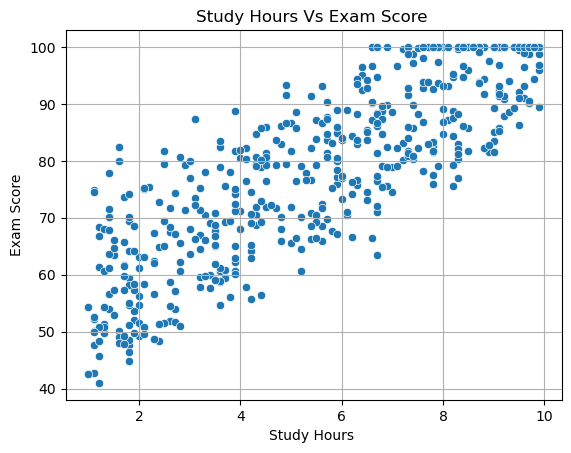

In [6]:
# Step No 6 : Exploratory Data Visualization

# Create Scatter Plot 
sns.scatterplot(
    x = "StudyHours",
    y = "ExamScore",
    data = df
)

# Set Plot title
plt.title("Study Hours Vs Exam Score ")

# Set x-axis label 
plt.xlabel(
    "Study Hours "
)

# Set y-axis label 
plt.ylabel(
    "Exam Score"
)

# Enable Grid 
plt.grid()

# Display Plot 
plt.show()

In [7]:
# Step No 7 : Train-Test Split 
# Split dataset into training and testing data 
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y, 
    test_size=0.20,
    random_state=42
)

# Display trianing samples 
print("\nTraining Samples : ")
print(len(X_train))

# Display testing samples 
print("\nTesting Samples : ")
print(len(X_test))


Training Samples : 
400

Testing Samples : 
100


In [8]:
# Step No 8 : Feature Scaling 

# Create StandardScaler Object 
scaler = StandardScaler()

# Fit scaler on training data 
# and transform training data
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform testing data 
# using the same fitted scaler
X_test_scaled = scaler.transform(
    X_test
)

In [9]:
# Step No 9 : Create Polynomial Kernel SVR
# Create Support Vector Regression Model 
# Using Polynomial Kernel
model = SVR(
    kernel="poly",
    degree=3 , 
    C = 100,
    gamma= "scale",
    epsilon=0.1
)

# Display Model 
print("\nPolynomial Kernel SVR Model : ")
print(model)


Polynomial Kernel SVR Model : 
SVR(C=100, kernel='poly')


In [10]:
# Step No 10 : Train Model 
# Train Polynomial Kernel SVR Model 
model.fit(
    X_train_scaled,
    y_train
)

# Display training message 
print(
    "\nModel Training Completed."
)


Model Training Completed.


In [11]:
# Step No 11 : Prediction 

# Predict Exam Scores 
y_pred = model.predict(
    X_test_scaled
)
# Display Predicted values 
print("\nPredicted Exam Scores : ")
print(y_pred)



Predicted Exam Scores : 
[ 80.65936514  90.34786665  42.3596872   63.78560378  86.95053681
  78.38931258  53.56595711  75.09127033  70.75223837  83.66491044
  84.90121017  68.099259    82.42225673  77.43122386  24.49679557
  75.79896735  69.09843459  83.52167494  78.71064987  90.02387685
  83.76050504  81.33957786  96.71789498  37.29270216  77.95005325
  79.65698293  52.43716628  82.76488734  78.06148018  58.48247417
 100.98540072 104.78817891  50.89717979  73.24351164  80.56030492
  59.10710353  57.19783737  83.24128624  71.20639124  63.75357599
  91.08765297  78.20142421  93.21099941  82.27536498  97.86547396
  72.29992817  79.31993763  99.14532429  78.659704    88.59152569
  46.70339694  89.66304408  81.40507732  77.68699643  77.28037193
  93.70591527  62.94173487  92.70555546  70.48363523  77.64767054
  78.15576863  65.3662485   75.62490996  69.55926004  62.63779624
  72.79109033  80.20142308  68.50264677  79.32248278  84.19504651
  77.25654488  80.40351904  84.65819723  44.987758

In [12]:
# Step No 12 : Model Evaluation 

# Calculate Mean Absolute Error 
mae = mean_absolute_error(
    y_test , 
    y_pred
)

# Calculate Mean Squared Error 
mse = mean_squared_error(
    y_test , 
    y_pred
)

# Calculate Root Mean Squared Error 
rmse = np.sqrt(
    mse
)

# Calculate R2 Score 
r2 = r2_score(
    y_test , 
    y_pred
)

# Display MAE 
print("\nMean Absolute Error : ")
print(mae)

# Display MSE
print("\nMean Squared Error : ")
print(mse)

# Display RMSE
print("\nRoot Mean Squared Error : ")
print(rmse)

# Display R2 Score 
print("\nR2 Score : ")
print(r2)


Mean Absolute Error : 
5.418079770781413

Mean Squared Error : 
52.86029946766805

Root Mean Squared Error : 
7.270508886430719

R2 Score : 
0.7786967086443417


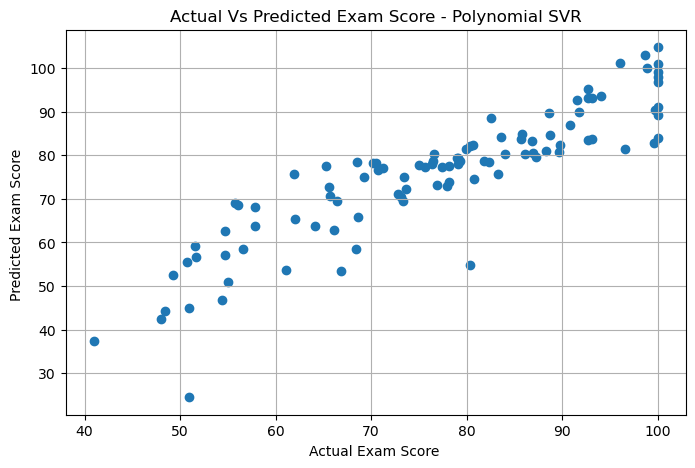

In [13]:
# Step No 13 : Actual Vs Predicted Visualization 
# Create scatter Plot 
plt.figure(
    figsize=(8,5)
)

# Plot actual Vs predicted values 
plt.scatter(
    y_test , 
    y_pred
)

# Set Plot Title 
plt.title("Actual Vs Predicted Exam Score - Polynomial SVR")

# Set x-axis label 
plt.xlabel(
    "Actual Exam Score "
)

# Set y-axis label 
plt.ylabel(
    "Predicted Exam Score "
)

# Enable grid 
plt.grid()

# Display Plot 
plt.show()

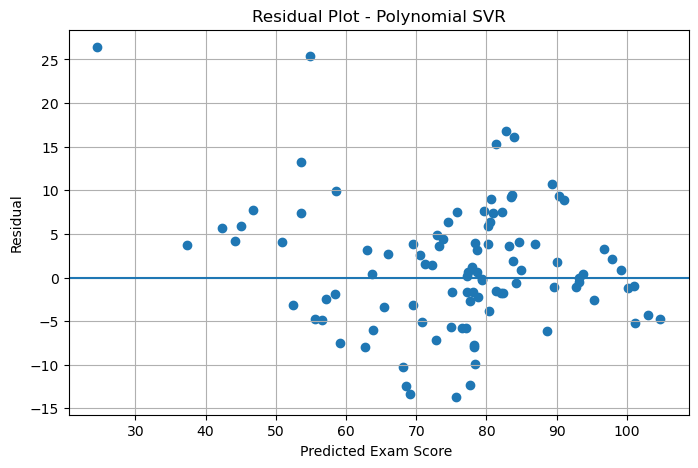

In [14]:
# Step No 14 : Residual Visualization 

# Calculate residuals 
residuals =  y_test.values - y_pred

# Create residual Plot 
plt.figure(figsize=(8 , 5))

# Plot residuals 

plt.scatter(
        y_pred , 
        residuals
    )


# Add Horizontal Zero Line 
plt.axhline(
    y = 0
)

# Set Plot Title 
plt.title(
    "Residual Plot - Polynomial SVR"
)

# Set x-axis label 
plt.xlabel("Predicted Exam Score ")

# Set y-axis label 
plt.ylabel("Residual")

# Enable grid 
plt.grid()

# Display Plot 
plt.show()

In [15]:
# Step No 15 : User Input 

# Take Study Hours Input 
study_hours = float(
    input(
        "\nEnter Study Hours : "
    )
)

# Take Attendance input 
attendance = float(
    input(
        "Enter Attendance(%)"
    )
)

# Take Assignment Score Input 
assignment_score = float(
    input(
        "Enter Assignment Score : "
    )
)

In [16]:
# Step No 16 : Create User DataFrame 

# Create DatFrame Using User Input 
user_data = pd.DataFrame({
    "StudyHours" : [study_hours] , 
    "Attendance" : [attendance],
    "AssignmentScore" : [assignment_score]
})

In [17]:
# Step No 17 : Scale User Input 

# Scale User Input Using 
# the already fitted scaler
user_data_scaled = scaler.transform(user_data)

In [18]:
# Step No 18 : Predict Exam Score 
# Predict Exam Score 
result = model.predict(
    user_data_scaled
)

In [19]:
# Step No 19 : Final Output 
print(
    "\nPredicted Exam Score : " , 
    round(
        result[0],
        2
    )
)


Predicted Exam Score :  132.48
